# Compare splines: nlad (sigmoid_Tianlu) vs new (modified_sigmoid)

Compares passing-fraction splines evaluated at the same (depth, cos θ, E) points:

- **nlad** — `/data/user/nlad/PassingFractions/spline_evaluator.py`, prpl built with `sigmoid_Tianlu` (39 depth slices, floor ≈ 0.6–0.8)
- **new** — `plights_tianlu/spline_evaluator.py`, prpl built with `modified_sigmoid` (50 depth slices, goes to 0 at low E)

No nuVeto re-evaluation — both evaluators read photospline `.fits` files.

In [62]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

PLIGHTS_DIR = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/passing_fraction/plights_tianlu"
NLAD_DIR    = "/data/user/nlad/PassingFractions"

# ── nlad's spline_evaluator: requires pf_logging on sys.path ─────────────────
sys.path.insert(0, NLAD_DIR)
import pf_logging

def _load_module(unique_name, file_path):
    spec = importlib.util.spec_from_file_location(unique_name, file_path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

nlad_mod = _load_module("spline_evaluator_nlad", os.path.join(NLAD_DIR,    "spline_evaluator.py"))
new_mod  = _load_module("spline_evaluator_new",  os.path.join(PLIGHTS_DIR, "spline_evaluator.py"))

Spline_Evaluator_nlad = nlad_mod.Spline_Evaluator
Spline_Evaluator_new  = new_mod.Spline_Evaluator

hdl_nlad = Spline_Evaluator_nlad()
hdl_new  = Spline_Evaluator_new()

# quick sanity: show spline extents
spline_nlad = list(hdl_nlad.spline_hdl.splines.values())[0][hdl_nlad._ethresh_hese]
print("nlad spline extents:", spline_nlad.extents)
print("new  spline extents:", list(hdl_new.splines.values())[0].extents)

DEBUG:spline_evaluator_new: Loaded spline: pf_spline_conv_nu_mu.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
DEBUG:spline_evaluator_new: Loaded spline: pf_spline_conv_nu_mubar.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
DEBUG:spline_evaluator_new: Loaded spline: pf_spline_conv_nu_e.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
DEBUG:spline_evaluator_new: Loaded spline: pf_spline_conv_nu_ebar.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
DEBUG:spline_evaluator_new: Loaded spline: pf_spline_pr_nu_mu.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
DEBUG:spline_evaluator_new: Loaded spline: pf_spline_pr_nu_mubar.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
DEBUG:spline_evaluator_new: Loaded spline: pf_spline_pr_nu_e.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
DEBUG:spline_evaluator_new: Loaded spline: pf_spline_pr_nu_ebar.fits (2026-08-29 06:08:14; spline_evaluator.py:58)
INFO:spline_evaluator_new: Loaded 8 splines from /data/user/tvaneede/GlobalFit/r

nlad spline extents: ((1300.0, 3100.0), (0.026250000000000002, 1.02375), (0.8823529411764706, 7.0))
new  spline extents: ((900.0, 3100.0), (0.026250000000000002, 1.02375), (0.92, 9.08))


## Choose kind and scan grids

In [ ]:
# ── Edit here ─────────────────────────────────────────────────────────────────
KIND = "conv nu_ebar"   # conv/pr  nu_mu/nu_mubar/nu_e/nu_ebar

ENERGIES_GEV    = np.logspace(2, 7, 6)                    # 100 GeV – 10 PeV
COS_THETAS      = np.round(np.arange(0.1, 1.01, 0.1), 2)

FIXED_DEPTH_M   = 1950.0    # for E and cos_theta scans
DEPTH_GRID_M    = np.linspace(1400, 2800, 8)  # within both spline ranges
FIXED_E_GEV     = 1e5
FIXED_COS_THETA = 0.5

_PID = {"nu_e": 12, "nu_ebar": -12, "nu_mu": 14, "nu_mubar": -14}
_, fltype = KIND.split(" ")
pid = np.array([_PID[fltype]])

PLOTS_DIR = os.path.join(PLIGHTS_DIR, "plots", "compare_spline_vs_nuveto",
                         KIND.replace(" ", "_"))
os.makedirs(PLOTS_DIR, exist_ok=True)

log_e = np.log10(ENERGIES_GEV)
n_e, n_ct, n_d = len(ENERGIES_GEV), len(COS_THETAS), len(DEPTH_GRID_M)
print(f"kind={KIND}  plots → {PLOTS_DIR}")

kind=conv nu_e  plots → /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/passing_fraction/plights_tianlu/plots/compare_spline_vs_nuveto/conv_nu_e


In [64]:
# ── Evaluate both splines over E × cos_theta at fixed depth ──────────────────
pf_nlad = np.zeros((n_e, n_ct))
pf_new  = np.zeros((n_e, n_ct))

for i, E in enumerate(ENERGIES_GEV):
    for j, ct in enumerate(COS_THETAS):
        zenith = np.arccos(ct)
        pf_nlad[i, j] = 10 ** hdl_nlad.evaluate(
            KIND, pid,
            np.array([FIXED_DEPTH_M]), np.array([zenith]), np.array([E])
        )[0]
        pf_new[i, j] = 10 ** hdl_new.evaluate_simple(KIND, FIXED_DEPTH_M, ct, E)

ratio_ec = np.where(pf_nlad > 0, pf_new / pf_nlad, np.nan)

# ── Depth scan ────────────────────────────────────────────────────────────────
pf_nlad_d = np.zeros(n_d)
pf_new_d  = np.zeros(n_d)

for k, dep in enumerate(DEPTH_GRID_M):
    zenith = np.arccos(FIXED_COS_THETA)
    pf_nlad_d[k] = 10 ** hdl_nlad.evaluate(
        KIND, pid,
        np.array([dep]), np.array([zenith]), np.array([FIXED_E_GEV])
    )[0]
    pf_new_d[k] = 10 ** hdl_new.evaluate_simple(KIND, dep, FIXED_COS_THETA, FIXED_E_GEV)

ratio_d = np.where(pf_nlad_d > 0, pf_new_d / pf_nlad_d, np.nan)
print("Done.")

INFO:spline_evaluator_nlad: Evaluating for component: conv (2026-08-29 06:08:14; spline_evaluator.py:65)
INFO:spline_evaluator_nlad: Evaluating for flavortype: nu_e (2026-08-29 06:08:14; spline_evaluator.py:66)
INFO:spline_evaluator_nlad: Evaluating for component: conv (2026-08-29 06:08:14; spline_evaluator.py:65)
INFO:spline_evaluator_nlad: Evaluating for flavortype: nu_e (2026-08-29 06:08:14; spline_evaluator.py:66)
INFO:spline_evaluator_nlad: Evaluating for component: conv (2026-08-29 06:08:14; spline_evaluator.py:65)
INFO:spline_evaluator_nlad: Evaluating for flavortype: nu_e (2026-08-29 06:08:14; spline_evaluator.py:66)
INFO:spline_evaluator_nlad: Evaluating for component: conv (2026-08-29 06:08:14; spline_evaluator.py:65)
INFO:spline_evaluator_nlad: Evaluating for flavortype: nu_e (2026-08-29 06:08:14; spline_evaluator.py:66)
INFO:spline_evaluator_nlad: Evaluating for component: conv (2026-08-29 06:08:14; spline_evaluator.py:65)
INFO:spline_evaluator_nlad: Evaluating for flavorty

Done.


DEBUG:matplotlib.ticker: vmin 0.41449067149927493 vmax 107693631.86182545 (2026-08-29 06:08:14; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09, 1.e+10]) (2026-08-29 06:08:14; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.41449067149927493 vmax 107693631.86182545 (2026-08-29 06:08:14; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05,

DEBUG:matplotlib.ticker: vmin 0.41449067149927493 vmax 107693631.86182545 (2026-08-29 06:08:14; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09, 1.e+10]) (2026-08-29 06:08:14; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.41449067149927493 vmax 107693631.86182545 (2026-08-29 06:08:14; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05,

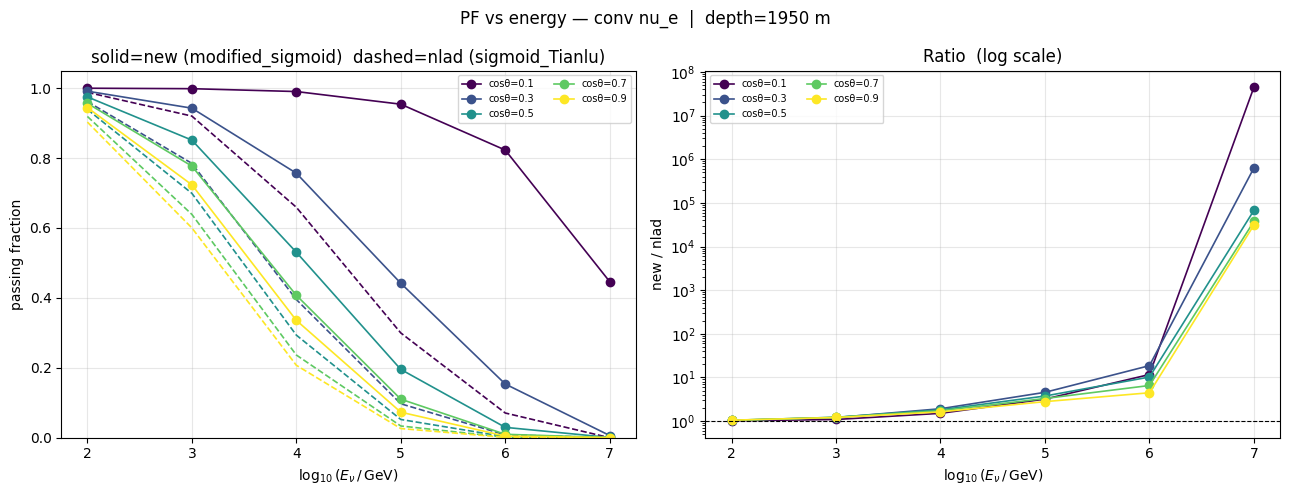

In [65]:
# PF vs energy  (every other cos_theta)
ct_indices = range(0, n_ct, 2)
colors_ct  = cm.viridis(np.linspace(0, 1, len(ct_indices)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"PF vs energy — {KIND}  |  depth={FIXED_DEPTH_M:.0f} m")

for plot_i, j in enumerate(ct_indices):
    ct = COS_THETAS[j]
    c  = colors_ct[plot_i]
    axes[0].plot(log_e, pf_nlad[:, j], "--", color=c, lw=1.2)
    axes[0].plot(log_e, pf_new[:, j],  "o-", color=c, lw=1.2, label=f"cosθ={ct:.1f}")
    axes[1].plot(log_e, ratio_ec[:, j], "o-", color=c, lw=1.2, label=f"cosθ={ct:.1f}")

axes[0].set_xlabel(r"$\log_{10}(E_\nu\,/\,\mathrm{GeV})$")
axes[0].set_ylabel("passing fraction")
axes[0].set_title("solid=new (modified_sigmoid)  dashed=nlad (sigmoid_Tianlu)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\log_{10}(E_\nu\,/\,\mathrm{GeV})$")
axes[1].set_ylabel("new / nlad")
axes[1].set_title("Ratio  (log scale)")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "pf_vs_energy.pdf"), bbox_inches="tight")
plt.show()

DEBUG:matplotlib.ticker: vmin 0.4144906714992749 vmax 107693631.86182545 (2026-08-29 06:08:15; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09, 1.e+10]) (2026-08-29 06:08:15; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.4144906714992749 vmax 107693631.86182545 (2026-08-29 06:08:15; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8

DEBUG:matplotlib.ticker: vmin 0.4144906714992749 vmax 107693631.86182545 (2026-08-29 06:08:15; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09, 1.e+10]) (2026-08-29 06:08:15; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.4144906714992749 vmax 107693631.86182545 (2026-08-29 06:08:15; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8

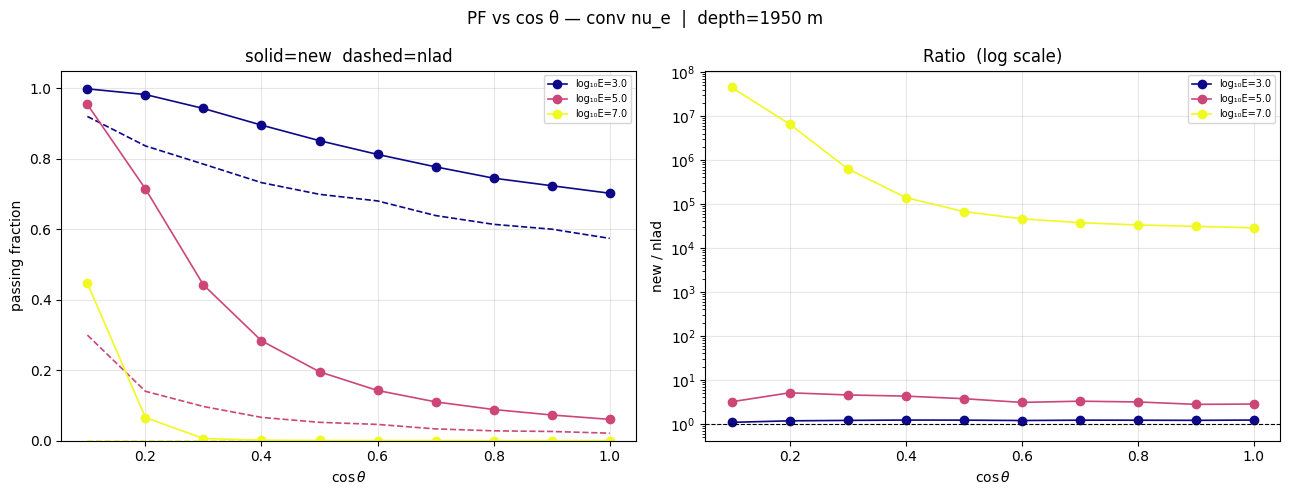

In [66]:
# PF vs cos_theta  (every other energy)
e_indices = range(1, n_e, 2)
colors_e  = cm.plasma(np.linspace(0, 1, len(e_indices)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"PF vs cos θ — {KIND}  |  depth={FIXED_DEPTH_M:.0f} m")

for plot_i, i in enumerate(e_indices):
    E   = ENERGIES_GEV[i]
    c   = colors_e[plot_i]
    lbl = f"log₁₀E={log_e[i]:.1f}"
    axes[0].plot(COS_THETAS, pf_nlad[i, :], "--", color=c, lw=1.2)
    axes[0].plot(COS_THETAS, pf_new[i, :],  "o-", color=c, lw=1.2, label=lbl)
    axes[1].plot(COS_THETAS, ratio_ec[i, :], "o-", color=c, lw=1.2, label=lbl)

axes[0].set_xlabel(r"$\cos\theta$")
axes[0].set_ylabel("passing fraction")
axes[0].set_title("solid=new  dashed=nlad")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\cos\theta$")
axes[1].set_ylabel("new / nlad")
axes[1].set_title("Ratio  (log scale)")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "pf_vs_costheta.pdf"), bbox_inches="tight")
plt.show()

DEBUG:matplotlib.colorbar: locator: <matplotlib.ticker.LogLocator object at 0x7f84454156a0> (2026-08-29 06:08:16; colorbar.py:872)
DEBUG:matplotlib.ticker: vmin 1.0 vmax 100000000.0 (2026-08-29 06:08:16; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06,
       1.e+07, 1.e+08, 1.e+09]) (2026-08-29 06:08:16; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 1.0 vmax 100000000.0 (2026-08-29 06:08:16; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8

DEBUG:matplotlib.ticker: vmin 1.0 vmax 100000000.0 (2026-08-29 06:08:16; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06,
       1.e+07, 1.e+08, 1.e+09]) (2026-08-29 06:08:16; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 1.0 vmax 100000000.0 (2026-08-29 06:08:16; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05,
       2.e+06, 3.e+06, 4.e+06, 5.e+06, 6.e+06, 7.e+06, 8.e+06, 9.e+06,
       2.e+07, 3.e+07, 4.e+07, 5.e+07, 6.e+07

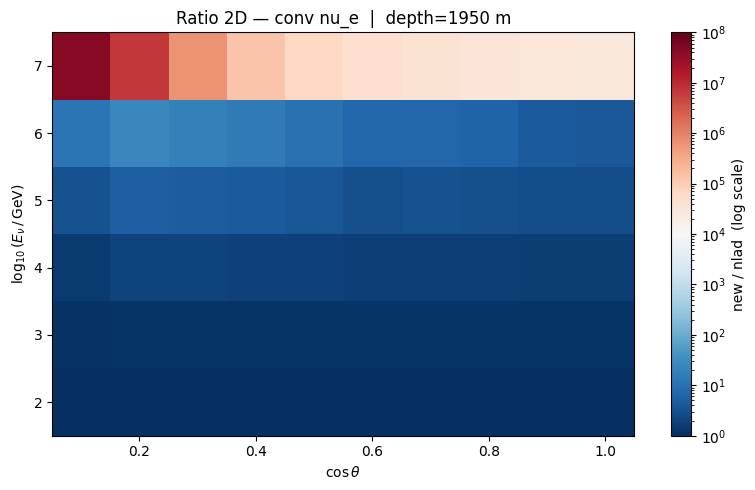

In [67]:
# Ratio heatmap (log scale)
import matplotlib.colors as mcolors

valid = ratio_ec[ratio_ec > 0]
vmin_log = 10 ** np.floor(np.log10(valid.min()))
vmax_log = 10 ** np.ceil(np.log10(valid.max()))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(COS_THETAS, log_e, ratio_ec,
                   cmap="RdBu_r",
                   norm=mcolors.LogNorm(vmin=vmin_log, vmax=vmax_log),
                   shading="auto")
fig.colorbar(im, ax=ax, label="new / nlad  (log scale)")
ax.set_xlabel(r"$\cos\theta$")
ax.set_ylabel(r"$\log_{10}(E_\nu\,/\,\mathrm{GeV})$")
ax.set_title(f"Ratio 2D — {KIND}  |  depth={FIXED_DEPTH_M:.0f} m")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ratio_2d.pdf"), bbox_inches="tight")
plt.show()

DEBUG:matplotlib.ticker: vmin 0.9260017556429256 vmax 5.025184231692676 (2026-08-29 06:08:17; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]) (2026-08-29 06:08:17; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.9260017556429256 vmax 5.025184231692676 (2026-08-29 06:08:17; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02]) (2026-08-29 06:08:17; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.9260017556429256 vmax 5.025184231692676 (2026-08-29 06:08:17; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]) (2026-08-29 06:08:17; ticker.py:2468)
DE

DEBUG:matplotlib.ticker: vmin 0.9260017556429256 vmax 5.025184231692676 (2026-08-29 06:08:17; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]) (2026-08-29 06:08:17; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.9260017556429256 vmax 5.025184231692676 (2026-08-29 06:08:17; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02]) (2026-08-29 06:08:17; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 0.9260017556429256 vmax 5.025184231692676 (2026-08-29 06:08:17; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]) (2026-08-29 06:08:17; ticker.py:2468)
DE

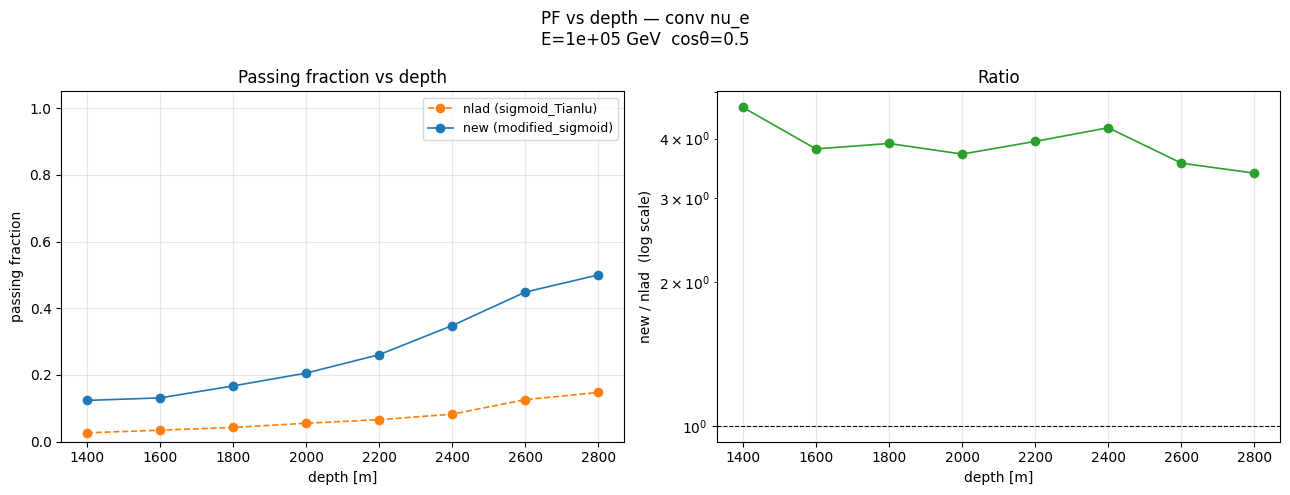

In [68]:
# PF vs depth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"PF vs depth — {KIND}\nE={FIXED_E_GEV:.0e} GeV  cosθ={FIXED_COS_THETA}")

axes[0].plot(DEPTH_GRID_M, pf_nlad_d, "o--", color="C1", lw=1.2, label="nlad (sigmoid_Tianlu)")
axes[0].plot(DEPTH_GRID_M, pf_new_d,  "o-",  color="C0", lw=1.2, label="new (modified_sigmoid)")
axes[0].set_xlabel("depth [m]")
axes[0].set_ylabel("passing fraction")
axes[0].set_title("Passing fraction vs depth")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].plot(DEPTH_GRID_M, ratio_d, "o-", color="C2", lw=1.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("depth [m]")
axes[1].set_ylabel("new / nlad  (log scale)")
axes[1].set_title("Ratio")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "pf_vs_depth.pdf"), bbox_inches="tight")
plt.show()

## MC comparison: sigmoid_Tianlu vs modified_sigmoid applied to datasets

Compares weighted event-rate histograms (fluxless_weight × AstroFlux × PassRate) from two MC sets:
- **nlad** — `PassRate_conv/prompt` computed with sigmoid_Tianlu splines
- **new** — `PassRate_conv/prompt` computed with modified_sigmoid splines (plights_tianlu)

In [69]:
import pandas as pd

# ── Edit here ─────────────────────────────────────────────────────────────────
PASSRATE_KEY = "PassRate_conv"   # "PassRate_conv"  or  "PassRate_prompt"
PID          = 12                # 12=nu_e  -12=nu_ebar  14=nu_mu  -14=nu_mubar

PATH_NLAD = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined/"
    "IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v8-v2_fluxlessweight/"
    "dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v8-v2_fluxlessweight.parquet"
)
PATH_NEW = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined/"
    "IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v8-v2_fluxlessweight_PassingHESE/"
    "dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v8-v2_fluxlessweight_PassingHESE.parquet"
)

_PID_LABEL = {12: r"$\nu_e$", -12: r"$\bar\nu_e$", 14: r"$\nu_\mu$", -14: r"$\bar\nu_\mu$"}

def AstroFluxModel(MCPrimaryEnergy):
    return 0.5 * (2.12e-18) * (MCPrimaryEnergy / 1e5) ** -2.87

COLS = ["MCPrimaryType", "MCPrimaryEnergy", "MCPrimaryZenith", "fluxless_weight", PASSRATE_KEY]

df_nlad = pd.read_parquet(PATH_NLAD, columns=COLS, engine="pyarrow")
df_new  = pd.read_parquet(PATH_NEW,  columns=COLS, engine="pyarrow")

# ── Filter by flavor ──────────────────────────────────────────────────────────
sel_nlad = df_nlad["MCPrimaryType"] == PID
sel_new  = df_new["MCPrimaryType"]  == PID

E_nlad  = df_nlad.loc[sel_nlad, "MCPrimaryEnergy"].values
E_new   = df_new.loc[sel_new,   "MCPrimaryEnergy"].values
zen_nlad = df_nlad.loc[sel_nlad, "MCPrimaryZenith"].values
zen_new  = df_new.loc[sel_new,   "MCPrimaryZenith"].values
cos_nlad = np.cos(zen_nlad)
cos_new  = np.cos(zen_new)

# weight = fluxless_weight × flux × PassRate
w_nlad = (df_nlad.loc[sel_nlad, "fluxless_weight"].values
          * AstroFluxModel(E_nlad)
          * df_nlad.loc[sel_nlad, PASSRATE_KEY].values)
w_new  = (df_new.loc[sel_new, "fluxless_weight"].values
          * AstroFluxModel(E_new)
          * df_new.loc[sel_new,  PASSRATE_KEY].values)

# ── Histogram bins ────────────────────────────────────────────────────────────
BINS_COS = np.linspace(0, 1,  41)
BINS_E   = np.linspace(3, 8,  41)   # log10(E/GeV)

h_nlad_cos, _ = np.histogram(cos_nlad, bins=BINS_COS, weights=w_nlad)
h_new_cos,  _ = np.histogram(cos_new,  bins=BINS_COS, weights=w_new)
h_nlad_e, _   = np.histogram(np.log10(E_nlad), bins=BINS_E, weights=w_nlad)
h_new_e,  _   = np.histogram(np.log10(E_new),  bins=BINS_E, weights=w_new)

ratio_cos = np.where(h_nlad_cos > 0, h_new_cos / h_nlad_cos, np.nan)
ratio_e   = np.where(h_nlad_e   > 0, h_new_e   / h_nlad_e,   np.nan)

MC_PLOTS_DIR = os.path.join(PLIGHTS_DIR, "plots", "compare_spline_vs_nuveto", "mc_datasets")
os.makedirs(MC_PLOTS_DIR, exist_ok=True)

print(f"flavor: {_PID_LABEL[PID]}   key: {PASSRATE_KEY}")
print(f"nlad events (selected): {sel_nlad.sum()}   new: {sel_new.sum()}")
print(f"plots → {MC_PLOTS_DIR}")

flavor: $\nu_e$   key: PassRate_conv
nlad events (selected): 226128   new: 226128
plots → /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/passing_fraction/plights_tianlu/plots/compare_spline_vs_nuveto/mc_datasets


/tmp/ipykernel_1101172/3150764395.py:59: RuntimeWarning: invalid value encountered in divide
  ratio_e   = np.where(h_nlad_e   > 0, h_new_e   / h_nlad_e,   np.nan)


DEBUG:matplotlib.ticker: vmin 1.3105761103591117e-11 vmax 1.6097833407916852e-09 (2026-08-29 06:08:18; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07]) (2026-08-29 06:08:18; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 1.3105761103591117e-11 vmax 1.6097833407916852e-09 (2026-08-29 06:08:18; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-12, 3.e-12, 4.e-12, 5.e-12, 6.e-12, 7.e-12, 8.e-12, 9.e-12,
       2.e-11, 3.e-11, 4.e-11, 5.e-11, 6.e-11, 7.e-11, 8.e-11, 9.e-11,
       2.e-10, 3.e-10, 4.e-10, 5.e-10, 6.e-10, 7.e-10, 8.e-10, 9.e-10,
       2.e-09, 3.e-09, 4.e-09, 5.e-09, 6.e-09, 7.e-09, 8.e-09, 9.e-09,
       2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07]) (2026-08-29 06:08:18; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 1.3105761103591117e-11 vmax 1.6097833407916852e-09 (2026-08-29 06:08:18; ticker.py:2419)
DEBUG:matplotlib

DEBUG:matplotlib.ticker: vmin 1.3105761103591117e-11 vmax 1.6097833407916852e-09 (2026-08-29 06:08:18; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07]) (2026-08-29 06:08:18; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 1.3105761103591117e-11 vmax 1.6097833407916852e-09 (2026-08-29 06:08:18; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07]) (2026-08-29 06:08:18; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 1.3105761103591117e-11 vmax 1.6097833407916852e-09 (2026-08-29 06:08:18; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-12, 3.e-12, 4.e-12, 5.e-12, 6.e-12, 7.e-12, 8.e-12, 9.e-12,
       2.e-11, 3.e-11, 4.e-11, 5.e-11, 6.e-11, 7.e-11, 8.e-11, 9.e-11,
       2.e-10, 3.e-10, 4.e-10, 5.e-10, 6.e-10, 7.e-10, 8.e-10, 9.e-10,
       2.e-09, 3.e-09, 4.e-09, 5.e-09, 6.e-09, 7.e-09, 8.e-09, 9.e-09,
       2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08

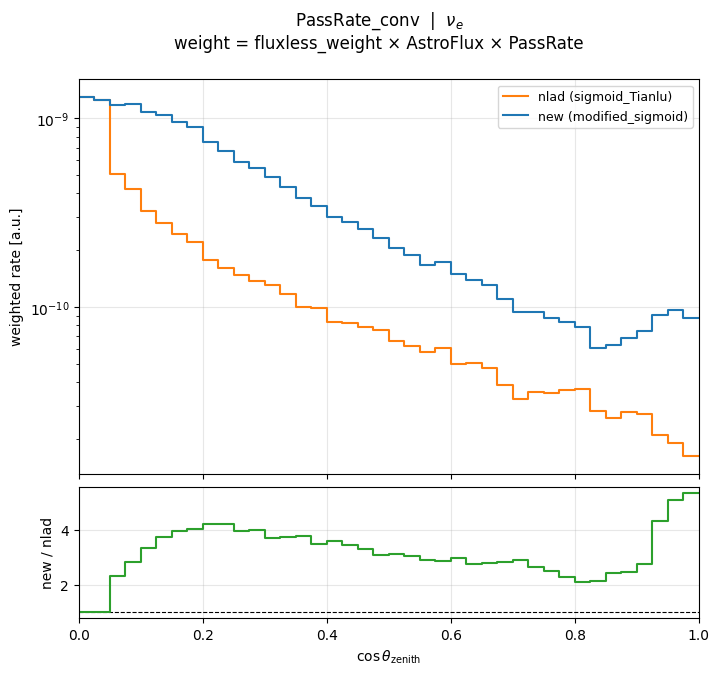

In [70]:
# Weighted rate vs cos(zenith)
cx = 0.5 * (BINS_COS[:-1] + BINS_COS[1:])

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
title = (f"{PASSRATE_KEY}  |  {_PID_LABEL[PID]}\n"
         f"weight = fluxless_weight × AstroFlux × PassRate")
fig.suptitle(title)

axes[0].step(BINS_COS, np.append(h_nlad_cos, h_nlad_cos[-1]), where="post",
             color="C1", lw=1.5, label="nlad (sigmoid_Tianlu)")
axes[0].step(BINS_COS, np.append(h_new_cos,  h_new_cos[-1]),  where="post",
             color="C0", lw=1.5, label="new (modified_sigmoid)")
axes[0].set_ylabel("weighted rate [a.u.]")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].step(BINS_COS, np.append(ratio_cos, ratio_cos[-1]), where="post", color="C2", lw=1.5)
axes[1].set_xlabel(r"$\cos\theta_\mathrm{zenith}$")
axes[1].set_ylabel("new / nlad")
axes[1].set_xlim(BINS_COS[0], BINS_COS[-1])
axes[1].grid(True, alpha=0.3)

plt.savefig(os.path.join(MC_PLOTS_DIR, f"{PASSRATE_KEY}_pid{PID}_vs_coszen.pdf"), bbox_inches="tight")
plt.show()

DEBUG:matplotlib.ticker: vmin 8.800946745719009e-14 vmax 1.2719559881735886e-08 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-15, 1.e-14, 1.e-13, 1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08,
       1.e-07, 1.e-06]) (2026-08-29 06:08:19; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 8.800946745719009e-14 vmax 1.2719559881735886e-08 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-15, 3.e-15, 4.e-15, 5.e-15, 6.e-15, 7.e-15, 8.e-15, 9.e-15,
       2.e-14, 3.e-14, 4.e-14, 5.e-14, 6.e-14, 7.e-14, 8.e-14, 9.e-14,
       2.e-13, 3.e-13, 4.e-13, 5.e-13, 6.e-13, 7.e-13, 8.e-13, 9.e-13,
       2.e-12, 3.e-12, 4.e-12, 5.e-12, 6.e-12, 7.e-12, 8.e-12, 9.e-12,
       2.e-11, 3.e-11, 4.e-11, 5.e-11, 6.e-11, 7.e-11, 8.e-11, 9.e-11,
       2.e-10, 3.e-10, 4.e-10, 5.e-10, 6.e-10, 7.e-10, 8.e-10, 9.e-10,
       2.e-09, 3.e-09, 4.e-09, 5.e-09, 6.e-09, 7.e-09, 8.e-09, 9.e-09,
       2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e

DEBUG:matplotlib.ticker: vmin 8.800946745719009e-14 vmax 1.2719559881735886e-08 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-15, 1.e-14, 1.e-13, 1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08,
       1.e-07, 1.e-06]) (2026-08-29 06:08:19; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 8.800946745719009e-14 vmax 1.2719559881735886e-08 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-15, 3.e-15, 4.e-15, 5.e-15, 6.e-15, 7.e-15, 8.e-15, 9.e-15,
       2.e-14, 3.e-14, 4.e-14, 5.e-14, 6.e-14, 7.e-14, 8.e-14, 9.e-14,
       2.e-13, 3.e-13, 4.e-13, 5.e-13, 6.e-13, 7.e-13, 8.e-13, 9.e-13,
       2.e-12, 3.e-12, 4.e-12, 5.e-12, 6.e-12, 7.e-12, 8.e-12, 9.e-12,
       2.e-11, 3.e-11, 4.e-11, 5.e-11, 6.e-11, 7.e-11, 8.e-11, 9.e-11,
       2.e-10, 3.e-10, 4.e-10, 5.e-10, 6.e-10, 7.e-10, 8.e-10, 9.e-10,
       2.e-09, 3.e-09, 4.e-09, 5.e-09, 6.e-09, 7.e-09, 8.e-09, 9.e-09,
       2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e

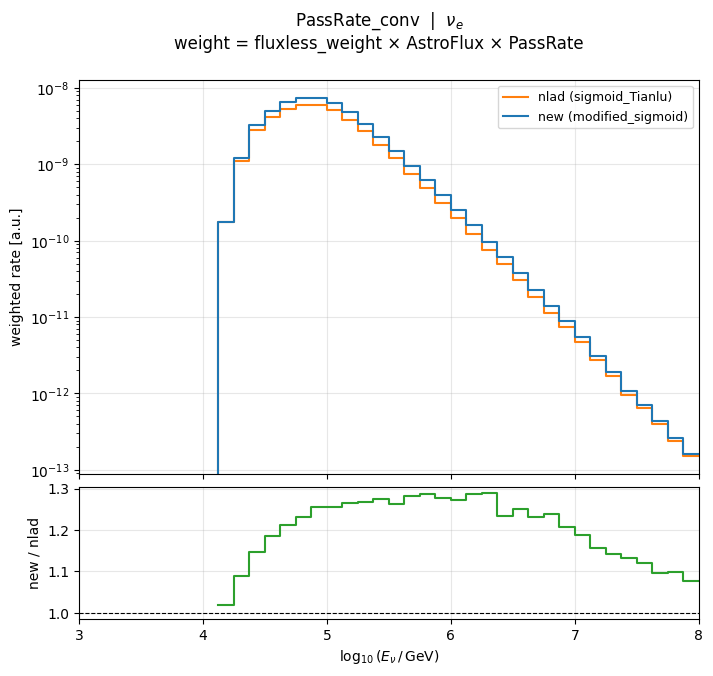

In [71]:
# Weighted rate vs log10(energy)
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
fig.suptitle(title)

axes[0].step(BINS_E, np.append(h_nlad_e, h_nlad_e[-1]), where="post",
             color="C1", lw=1.5, label="nlad (sigmoid_Tianlu)")
axes[0].step(BINS_E, np.append(h_new_e,  h_new_e[-1]),  where="post",
             color="C0", lw=1.5, label="new (modified_sigmoid)")
axes[0].set_ylabel("weighted rate [a.u.]")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].step(BINS_E, np.append(ratio_e, ratio_e[-1]), where="post", color="C2", lw=1.5)
axes[1].set_xlabel(r"$\log_{10}(E_\nu\,/\,\mathrm{GeV})$")
axes[1].set_ylabel("new / nlad")
axes[1].set_xlim(BINS_E[0], BINS_E[-1])
axes[1].grid(True, alpha=0.3)

plt.savefig(os.path.join(MC_PLOTS_DIR, f"{PASSRATE_KEY}_pid{PID}_vs_energy.pdf"), bbox_inches="tight")
plt.show()

/tmp/ipykernel_1101172/2465433696.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio_pf = np.where(h_nlad_pf > 0, h_new_pf / h_nlad_pf, np.nan)
/tmp/ipykernel_1101172/2465433696.py:13: RuntimeWarning: invalid value encountered in divide
  ratio_pf = np.where(h_nlad_pf > 0, h_new_pf / h_nlad_pf, np.nan)
DEBUG:matplotlib.ticker: vmin 4.384592935825221e-15 vmax 1.0049486443069856e-07 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-16, 1.e-15, 1.e-14, 1.e-13, 1.e-12, 1.e-11, 1.e-10, 1.e-09,
       1.e-08, 1.e-07, 1.e-06, 1.e-05]) (2026-08-29 06:08:19; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 4.384592935825221e-15 vmax 1.0049486443069856e-07 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-16, 3.e-16, 4.e-16, 5.e-16, 6.e-16, 7.e-16, 8.e-16, 9.e-16,
       2.e-15, 3.e-15, 4.e-15, 5.e-15, 6.e-15, 7.e-15, 8.e-15, 9.e-15,
       2.e-14, 3.e-14, 4.e-14, 5.e-14, 6.e-14, 7.e-14, 8.e-14, 9.e-14,
       2.e-13

DEBUG:matplotlib.ticker: vmin 4.384592935825221e-15 vmax 1.0049486443069856e-07 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([1.e-16, 1.e-15, 1.e-14, 1.e-13, 1.e-12, 1.e-11, 1.e-10, 1.e-09,
       1.e-08, 1.e-07, 1.e-06, 1.e-05]) (2026-08-29 06:08:19; ticker.py:2468)
DEBUG:matplotlib.ticker: vmin 4.384592935825221e-15 vmax 1.0049486443069856e-07 (2026-08-29 06:08:19; ticker.py:2419)
DEBUG:matplotlib.ticker: ticklocs array([2.e-16, 3.e-16, 4.e-16, 5.e-16, 6.e-16, 7.e-16, 8.e-16, 9.e-16,
       2.e-15, 3.e-15, 4.e-15, 5.e-15, 6.e-15, 7.e-15, 8.e-15, 9.e-15,
       2.e-14, 3.e-14, 4.e-14, 5.e-14, 6.e-14, 7.e-14, 8.e-14, 9.e-14,
       2.e-13, 3.e-13, 4.e-13, 5.e-13, 6.e-13, 7.e-13, 8.e-13, 9.e-13,
       2.e-12, 3.e-12, 4.e-12, 5.e-12, 6.e-12, 7.e-12, 8.e-12, 9.e-12,
       2.e-11, 3.e-11, 4.e-11, 5.e-11, 6.e-11, 7.e-11, 8.e-11, 9.e-11,
       2.e-10, 3.e-10, 4.e-10, 5.e-10, 6.e-10, 7.e-10, 8.e-10, 9.e-10,
       2.e-09, 3.e-09, 4.e-09, 5.e-09, 6.e-09, 7.e

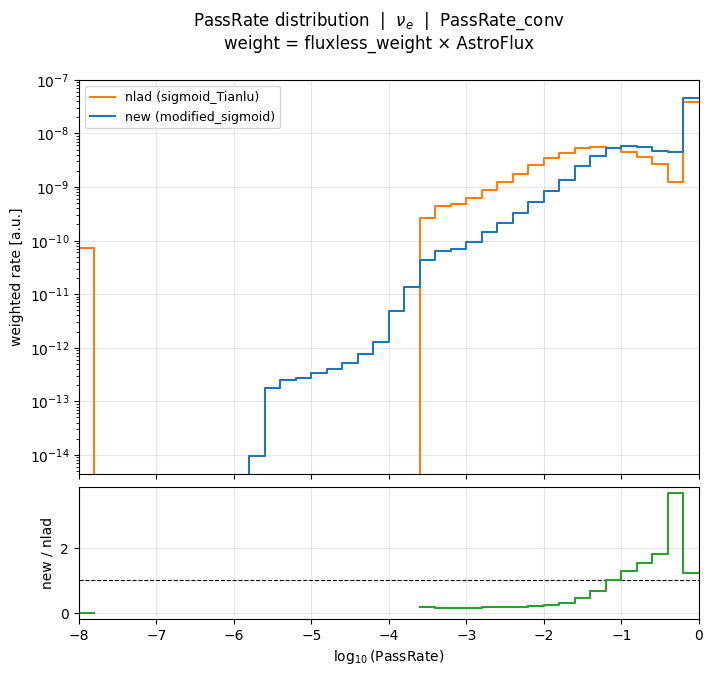

In [72]:
# Histogram of the passing fraction values (weighted by fluxless_weight × AstroFlux)
pr_nlad = df_nlad.loc[sel_nlad, PASSRATE_KEY].values
pr_new  = df_new.loc[sel_new,   PASSRATE_KEY].values

w_flux_nlad = df_nlad.loc[sel_nlad, "fluxless_weight"].values * AstroFluxModel(E_nlad)
w_flux_new  = df_new.loc[sel_new,   "fluxless_weight"].values * AstroFluxModel(E_new)

BINS_PF = np.linspace(-8, 0, 41)   # log10(PassRate)

h_nlad_pf, _ = np.histogram(np.log10(np.clip(pr_nlad, 1e-8, 1)), bins=BINS_PF, weights=w_flux_nlad)
h_new_pf,  _ = np.histogram(np.log10(np.clip(pr_new,  1e-8, 1)), bins=BINS_PF, weights=w_flux_new)

ratio_pf = np.where(h_nlad_pf > 0, h_new_pf / h_nlad_pf, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
fig.suptitle(f"PassRate distribution  |  {_PID_LABEL[PID]}  |  {PASSRATE_KEY}\n"
             f"weight = fluxless_weight × AstroFlux")

axes[0].step(BINS_PF, np.append(h_nlad_pf, h_nlad_pf[-1]), where="post",
             color="C1", lw=1.5, label="nlad (sigmoid_Tianlu)")
axes[0].step(BINS_PF, np.append(h_new_pf,  h_new_pf[-1]),  where="post",
             color="C0", lw=1.5, label="new (modified_sigmoid)")
axes[0].set_ylabel("weighted rate [a.u.]")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].step(BINS_PF, np.append(ratio_pf, ratio_pf[-1]), where="post", color="C2", lw=1.5)
axes[1].set_xlabel(r"$\log_{10}(\mathrm{PassRate})$")
axes[1].set_ylabel("new / nlad")
axes[1].set_xlim(BINS_PF[0], BINS_PF[-1])
axes[1].grid(True, alpha=0.3)

plt.savefig(os.path.join(MC_PLOTS_DIR, f"{PASSRATE_KEY}_pid{PID}_pf_distribution.pdf"), bbox_inches="tight")
plt.show()